# DeepLabV3+-ResNet50 Transfer Learning: CHASEDB1 → DRIVE

**Task:** Binary retinal vessel segmentation.

This notebook follows the same training style as `02_SegFormer_B0_DRIVE.ipynb`, but replaces SegFormer-B0 with **DeepLabV3+-ResNet50**.

Pipeline:
1. Clone GitHub repo and set working directory.
2. Set random seed and shared training configuration.
3. Load processed CHASEDB1 as the **source dataset**.
4. Load processed DRIVE as the **target / transfer dataset**.
5. Build **DeepLabV3+-ResNet50** for binary segmentation.
6. Pretrain on CHASEDB1.
7. Load CHASEDB1 checkpoint and fine-tune on DRIVE.
8. Evaluate on DRIVE validation/test sets.
9. Visualize segmentation results as **Image | Ground Truth | Prediction**.

Common parameters such as `SEED`, `IMG_SIZE`, `BATCH_SIZE`, `NUM_EPOCHS`, `LR`, `WEIGHT_DECAY`, `PATIENCE`, `BEST_METRIC`, and `AMP` follow the SegFormer notebook style. Dataset-specific parameters are separated for CHASEDB1 and DRIVE so they can be tuned independently.

In [1]:
!pip -q install albumentations opencv-python tqdm pandas matplotlib

In [2]:
from pathlib import Path
import os
import sys

REPO_URL = "https://github.com/DannyPhongcoderso1/DL-retinal-vessel-segmentation-final.git"
REPO_DIR = Path("/kaggle/working/DL-retinal-vessel-segmentation-final")

if not REPO_DIR.exists():
    !git clone {REPO_URL} {REPO_DIR}

os.chdir(REPO_DIR)
if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))

print("Using repo:", REPO_DIR)
print("CWD:", Path.cwd())

Cloning into '/kaggle/working/DL-retinal-vessel-segmentation-final'...
remote: Enumerating objects: 152, done.
remote: Counting objects: 100% (97/97), done.
remote: Compressing objects: 100% (75/75), done.
remote: Total 152 (delta 49), reused 55 (delta 21), pack-reused 55 (from 1)
Receiving objects: 100% (152/152), 87.40 MiB | 42.06 MiB/s, done.
Resolving deltas: 100% (67/67), done.
Using repo: /kaggle/working/DL-retinal-vessel-segmentation-final
CWD: /kaggle/working/DL-retinal-vessel-segmentation-final


In [3]:
import os
from pathlib import Path
import random
import zipfile
import gc

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt



def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

## 1. Shared configuration

These parameters are shared across CHASEDB1 source training and DRIVE transfer training. You can tune the dataset-specific blocks below without changing the whole notebook.

In [ ]:
# ============================================================
# COMMON TRAINING CONFIGURATION
# Shared by CHASEDB1 and DRIVE
# ============================================================

SEED = 42
set_seed(SEED)

WORK_DIR = Path("/kaggle/working")

IMG_SIZE = 512
BATCH_SIZE = 2
NUM_WORKERS = 0
PIN_MEMORY = torch.cuda.is_available()
AMP = True

THRESHOLD = 0.50
THRESHOLD_SEARCH_VALUES = np.arange(0.30, 0.81, 0.05)

WEIGHT_DECAY = 1e-4
BEST_METRIC = "dice"  # "dice" or "iou"

SAVE_DIR = Path("/kaggle/working/deeplabv3plus_resnet50_outputs")
CHECKPOINT_DIR = SAVE_DIR / "checkpoints"
PREDICTIONS_DIR = SAVE_DIR / "predictions"
HISTORY_DIR = SAVE_DIR / "history"
RESULTS_DIR = SAVE_DIR / "results"

for path in [SAVE_DIR, CHECKPOINT_DIR, PREDICTIONS_DIR, HISTORY_DIR, RESULTS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("DEVICE:", DEVICE)
print("AMP:", AMP)
print("CUDA available:", torch.cuda.is_available())
print("Number of GPUs:", torch.cuda.device_count())

for i in range(torch.cuda.device_count()):
    print(f"GPU {i}:", torch.cuda.get_device_name(i))

DEVICE: cuda
AMP: True
CUDA available: True
Number of GPUs: 2
GPU 0: Tesla T4
GPU 1: Tesla T4


## 2. Dataset configuration

This notebook expects processed datasets in the same `.pt` format used by the SegFormer notebook:

```text
DATA_ROOT/
  train/*.pt
  val/*.pt
  test/*.pt
```

Each `.pt` sample should contain `image` and one of `manual`, `manual_2`, or `mask`. Update the Kaggle dataset paths/slugs below to match your uploaded datasets.

In [ ]:
# ============================================================
# SOURCE DATASET: CHASEDB1
# ============================================================

CHASE_DATA_DIR = Path("/kaggle/input/datasets/ngchnhphong/dl-src-transfer-dataset")  # update if needed
CHASE_ZIP_PATH = CHASE_DATA_DIR / "CHASE_processed_dataset.zip"                       # update filename if needed
CHASE_EXTRACT_DIR = WORK_DIR / "CHASE_processed_dataset"

CHASE_IMG_SIZE = IMG_SIZE
CHASE_BATCH_SIZE = BATCH_SIZE

# CHASE source training
CHASE_NUM_EPOCHS = 40
CHASE_PATIENCE = 10
CHASE_LR_BACKBONE = 1e-5
CHASE_LR_HEAD = 1e-4

CHASE_BEST_MODEL_PATH = CHECKPOINT_DIR / "best_deeplabv3plus_resnet50_chase.pth"
CHASE_HISTORY_PATH = HISTORY_DIR / "deeplabv3plus_resnet50_chase_history.csv"
CHASE_RESULTS_PATH = RESULTS_DIR / "deeplabv3plus_resnet50_chase_results.csv"

# ============================================================
# TARGET DATASET: DRIVE
# ============================================================

DRIVE_DATA_DIR = Path("/kaggle/input/datasets/ngchnhphong/dl-src-transfer-dataset")
DRIVE_ZIP_PATH = DRIVE_DATA_DIR / "DRIVE_processed_dataset.zip"
DRIVE_EXTRACT_DIR = WORK_DIR / "DRIVE_processed_dataset"

DRIVE_IMG_SIZE = IMG_SIZE
DRIVE_BATCH_SIZE = BATCH_SIZE

# DRIVE transfer / fine-tuning
DRIVE_NUM_EPOCHS = 50
DRIVE_PATIENCE = 12
DRIVE_LR_BACKBONE = 5e-6
DRIVE_LR_HEAD = 5e-5

# Optional phase-1 head-only warmup
HEAD_ONLY_EPOCHS = 5
HEAD_ONLY_LR = 1e-3

DRIVE_BEST_MODEL_PATH = CHECKPOINT_DIR / "best_deeplabv3plus_resnet50_drive.pth"
DRIVE_HISTORY_PATH = HISTORY_DIR / "deeplabv3plus_resnet50_drive_history.csv"
DRIVE_RESULTS_PATH = RESULTS_DIR / "deeplabv3plus_resnet50_drive_test_results.csv"
DRIVE_PREDICTIONS_DIR = PREDICTIONS_DIR / "drive_test"

In [6]:
def resolve_processed_dataset_root(data_dir: Path, zip_path: Path, extract_dir: Path) -> Path:
    # Resolve a processed dataset root containing train/val/test folders.
    if zip_path.exists():
        if not extract_dir.exists() or not all((extract_dir / split).exists() for split in ("train", "val", "test")):
            extract_dir.mkdir(parents=True, exist_ok=True)
            with zipfile.ZipFile(zip_path, "r") as zf:
                zf.extractall(extract_dir)

    for root in (extract_dir, data_dir):
        if all((root / split).exists() for split in ("train", "val", "test")):
            return root
        if root.exists():
            for child in root.iterdir():
                if child.is_dir() and all((child / split).exists() for split in ("train", "val", "test")):
                    return child

    raise FileNotFoundError(f"Could not find processed dataset root with train/val/test under {data_dir} or {extract_dir}.")

CHASE_ROOT = resolve_processed_dataset_root(CHASE_DATA_DIR, CHASE_ZIP_PATH, CHASE_EXTRACT_DIR)
DRIVE_ROOT = resolve_processed_dataset_root(DRIVE_DATA_DIR, DRIVE_ZIP_PATH, DRIVE_EXTRACT_DIR)

print("CHASE_ROOT:", CHASE_ROOT)
print("CHASE train files:", len(list((CHASE_ROOT / "train").glob("*.pt"))))
print("DRIVE_ROOT:", DRIVE_ROOT)
print("DRIVE train files:", len(list((DRIVE_ROOT / "train").glob("*.pt"))))

CHASE_ROOT: /kaggle/input/datasets/ngchnhphong/dl-src-transfer-dataset/DRIVE_processed_dataset
CHASE train files: 80
DRIVE_ROOT: /kaggle/input/datasets/ngchnhphong/dl-src-transfer-dataset/DRIVE_processed_dataset
DRIVE train files: 80


## 3. Dataset and DataLoader

The same dataset class is reused for CHASEDB1 and DRIVE to keep the data pipeline consistent with the SegFormer notebook.

In [7]:
IMAGENET_MEAN_TENSOR = torch.tensor([0.485, 0.456, 0.406], dtype=torch.float32).view(3, 1, 1)
IMAGENET_STD_TENSOR = torch.tensor([0.229, 0.224, 0.225], dtype=torch.float32).view(3, 1, 1)


def prepare_retina_image(image: torch.Tensor) -> torch.Tensor:
    # Normalize RGB image with ImageNet mean/std for ResNet50 backbone.
    image = image.float()
    if image.dim() != 3 or image.shape[0] != 3:
        raise ValueError(f"Expected image [3, H, W], got {tuple(image.shape)}")

    min_value = float(image.min())
    max_value = float(image.max())
    if min_value >= 0.0 and max_value > 1.0:
        image = image / 255.0
        image = (image - IMAGENET_MEAN_TENSOR) / IMAGENET_STD_TENSOR
    elif min_value >= 0.0 and max_value <= 1.0:
        image = (image - IMAGENET_MEAN_TENSOR) / IMAGENET_STD_TENSOR
    return image


class RetinalProcessedDataset(Dataset):
    def __init__(self, root_dir: Path, split: str, img_size: int | None = None):
        self.root_dir = Path(root_dir)
        self.split = split
        self.files = sorted((self.root_dir / split).glob("*.pt"))
        self.img_size = img_size
        if len(self.files) == 0:
            raise FileNotFoundError(f"No .pt files found in {self.root_dir / split}")

    def __len__(self) -> int:
        return len(self.files)

    def __getitem__(self, idx: int):
        sample = torch.load(self.files[idx], map_location="cpu")
        image = sample.get("image")
        mask = sample.get("manual")
        if mask is None:
            mask = sample.get("manual_2")
        if mask is None:
            mask = sample.get("mask")
        if image is None:
            raise KeyError(f"Sample {self.files[idx]} does not contain key 'image'.")
        if mask is None:
            raise KeyError(f"Sample {self.files[idx]} does not contain manual/manual_2/mask.")

        if not torch.is_tensor(image):
            image = torch.tensor(image)
        if image.dim() == 3 and image.shape[0] != 3:
            image = image.permute(2, 0, 1)
        image = prepare_retina_image(image)

        if not torch.is_tensor(mask):
            mask = torch.tensor(mask)
        mask = mask.float()
        if mask.dim() == 2:
            mask = mask.unsqueeze(0)
        elif mask.dim() == 3 and mask.shape[0] != 1:
            if mask.shape[-1] in (1, 3):
                mask = mask.permute(2, 0, 1)
            if mask.shape[0] != 1:
                mask = mask[:1]
        if mask.max() > 1.0:
            mask = mask / 255.0
        mask = (mask > 0.5).float()
        if mask.shape[0] != 1:
            raise ValueError(f"Expected mask [1, H, W], got {tuple(mask.shape)}")

        if self.img_size is not None:
            target_size = (self.img_size, self.img_size)
            if image.shape[-2:] != target_size:
                image = F.interpolate(image.unsqueeze(0), size=target_size, mode="bilinear", align_corners=False).squeeze(0)
            if mask.shape[-2:] != target_size:
                mask = F.interpolate(mask.unsqueeze(0), size=target_size, mode="nearest").squeeze(0)
        return image, mask


def build_loaders(root: Path, img_size: int, batch_size: int):
    train_ds = RetinalProcessedDataset(root, "train", img_size=img_size)
    val_ds = RetinalProcessedDataset(root, "val", img_size=img_size)
    test_ds = RetinalProcessedDataset(root, "test", img_size=img_size)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
    return train_ds, val_ds, test_ds, train_loader, val_loader, test_loader


chase_train_ds, chase_val_ds, chase_test_ds, chase_train_loader, chase_val_loader, chase_test_loader = build_loaders(
    CHASE_ROOT, img_size=CHASE_IMG_SIZE, batch_size=CHASE_BATCH_SIZE
)

drive_train_ds, drive_val_ds, drive_test_ds, drive_train_loader, drive_val_loader, drive_test_loader = build_loaders(
    DRIVE_ROOT, img_size=DRIVE_IMG_SIZE, batch_size=DRIVE_BATCH_SIZE
)

print("CHASE train/val/test:", len(chase_train_ds), len(chase_val_ds), len(chase_test_ds))
print("DRIVE train/val/test:", len(drive_train_ds), len(drive_val_ds), len(drive_test_ds))

CHASE train/val/test: 80 4 20
DRIVE train/val/test: 80 4 20


In [ ]:
# ============================================================
# SANITY CHECK: BINARY MASKS
# ============================================================

images, masks = next(iter(drive_train_loader))
print("Image batch:", images.shape, images.dtype, images.min().item(), images.max().item())
print("Mask batch :", masks.shape, masks.dtype, masks.min().item(), masks.max().item())
print("Unique mask values:", torch.unique(masks))

## 4. DeepLabV3+-ResNet50 model

The model uses a **DeepLabV3** segmentation head with a **ResNet50** CNN backbone. The final classifier is replaced to output `1` binary vessel logit channel.

In [8]:
from src.models.deeplabv3plus_resnet50 import DeepLabV3PlusResNet50Binary

def maybe_wrap_dataparallel(model: nn.Module) -> nn.Module:
    model = model.to(DEVICE)

    if torch.cuda.is_available() and torch.cuda.device_count() > 1:
        print(f"Using {torch.cuda.device_count()} GPUs with DataParallel")
        model = nn.DataParallel(model)

    return model


def build_deeplabv3plus_resnet50(pretrained_backbone: bool = True) -> nn.Module:
    model = DeepLabV3PlusResNet50Binary(
        pretrained_backbone=pretrained_backbone,
        output_stride=16,
    )
    model = maybe_wrap_dataparallel(model)
    return model

In [ ]:
# ============================================================
# MODEL SANITY CHECK
# ============================================================

model = build_deeplabv3plus_resnet50(pretrained_backbone=True)
images, masks = next(iter(drive_train_loader))

with torch.no_grad():
    logits = model(images.to(DEVICE))
    if isinstance(logits, dict):
        logits = logits["out"]

expected_shape = (images.size(0), 1, images.size(2), images.size(3))
assert images.ndim == 4 and images.size(1) == 3, f"Expected input [B, 3, H, W], got {tuple(images.shape)}"
assert tuple(masks.shape) == expected_shape, f"Expected masks {expected_shape}, got {tuple(masks.shape)}"
assert tuple(logits.shape) == expected_shape, f"Expected logits {expected_shape}, got {tuple(logits.shape)}"

print("input :", images.shape)
print("masks :", masks.shape)
print("logits:", logits.shape)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 187MB/s] 


Using 2 GPUs with DataParallel
input : torch.Size([8, 3, 512, 512])
masks : torch.Size([8, 1, 512, 512])
logits: torch.Size([8, 1, 512, 512])


## 5. Loss, metrics, early stopping, and training functions

This section follows the SegFormer notebook training style: **BCE + Dice Loss**, `AdamW`, `AMP`, early stopping, and best checkpoint saving.

In [ ]:
import copy

from torch.cuda.amp import autocast, GradScaler


class DiceLoss(nn.Module):
    def __init__(self, smooth: float = 1e-7):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        probs = torch.sigmoid(logits)
        targets = targets.float()

        probs = probs.view(probs.size(0), -1)
        targets = targets.view(targets.size(0), -1)

        intersection = (probs * targets).sum(dim=1)
        denominator = probs.sum(dim=1) + targets.sum(dim=1)

        dice = (2.0 * intersection + self.smooth) / (denominator + self.smooth)
        return 1.0 - dice.mean()


class TverskyLoss(nn.Module):
    def __init__(self, alpha: float = 0.3, beta: float = 0.7, smooth: float = 1e-7):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.smooth = smooth

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        probs = torch.sigmoid(logits)
        targets = targets.float()

        probs = probs.view(probs.size(0), -1)
        targets = targets.view(targets.size(0), -1)

        tp = (probs * targets).sum(dim=1)
        fp = (probs * (1.0 - targets)).sum(dim=1)
        fn = ((1.0 - probs) * targets).sum(dim=1)

        tversky = (tp + self.smooth) / (tp + self.alpha * fp + self.beta * fn + self.smooth)
        return 1.0 - tversky.mean()


class BCEDiceLoss(nn.Module):
    def __init__(
        self,
        bce_weight: float = 0.5,
        dice_weight: float = 0.5,
        pos_weight: torch.Tensor | None = None,
    ):
        super().__init__()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
        self.bce = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        self.dice = DiceLoss()

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        targets = targets.float()
        bce_loss = self.bce(logits, targets)
        dice_loss = self.dice(logits, targets)
        return self.bce_weight * bce_loss + self.dice_weight * dice_loss


class BCETverskyLoss(nn.Module):
    def __init__(
        self,
        bce_weight: float = 0.3,
        tversky_weight: float = 0.7,
        alpha: float = 0.3,
        beta: float = 0.7,
        pos_weight: torch.Tensor | None = None,
    ):
        super().__init__()
        self.bce_weight = bce_weight
        self.tversky_weight = tversky_weight
        self.bce = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        self.tversky = TverskyLoss(alpha=alpha, beta=beta)

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        targets = targets.float()
        bce_loss = self.bce(logits, targets)
        tversky_loss = self.tversky(logits, targets)
        return self.bce_weight * bce_loss + self.tversky_weight * tversky_loss


def unwrap_model(model: nn.Module) -> nn.Module:
    return model.module if isinstance(model, nn.DataParallel) else model


def compute_pos_weight(loader, device, max_weight: float = 10.0) -> torch.Tensor:
    pos_pixels = 0.0
    neg_pixels = 0.0

    for _, masks in loader:
        masks = masks.float()
        pos_pixels += masks.sum().item()
        neg_pixels += (1.0 - masks).sum().item()

    raw_weight = neg_pixels / max(pos_pixels, 1.0)
    clipped_weight = min(raw_weight, max_weight)

    print(f"Positive pixels: {pos_pixels:.0f}")
    print(f"Negative pixels: {neg_pixels:.0f}")
    print(f"Raw pos_weight: {raw_weight:.4f}")
    print(f"Clipped pos_weight: {clipped_weight:.4f}")

    return torch.tensor([clipped_weight], dtype=torch.float32, device=device)


def build_deeplab_optimizer(model, lr_backbone: float, lr_head: float, weight_decay: float = 1e-4):
    core_model = unwrap_model(model)
    param_groups = []

    if hasattr(core_model, "backbone"):
        param_groups.append({
            "params": core_model.backbone.parameters(),
            "lr": lr_backbone,
        })
    else:
        print("Warning: backbone not found. Using full model parameters as backbone group.")
        param_groups.append({
            "params": core_model.parameters(),
            "lr": lr_backbone,
        })

    if hasattr(core_model, "classifier"):
        param_groups.append({
            "params": core_model.classifier.parameters(),
            "lr": lr_head,
        })

    return torch.optim.AdamW(param_groups, weight_decay=weight_decay)


def freeze_backbone(model):
    core_model = unwrap_model(model)
    if hasattr(core_model, "backbone"):
        for param in core_model.backbone.parameters():
            param.requires_grad = False
        print("Backbone frozen.")
    else:
        print("Warning: backbone not found. Nothing frozen.")


def unfreeze_all(model):
    for param in model.parameters():
        param.requires_grad = True
    print("All model parameters unfrozen.")


def count_trainable_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters: {total:,}")
    print(f"Trainable parameters: {trainable:,}")
    print(f"Frozen parameters: {total - trainable:,}")


def get_model_state_dict(model: nn.Module):
    if isinstance(model, nn.DataParallel):
        return model.module.state_dict()
    return model.state_dict()


def load_model_state_dict_safely(model: nn.Module, state_dict):
    if isinstance(model, nn.DataParallel):
        model.module.load_state_dict(state_dict)
    else:
        model.load_state_dict(state_dict)


def compute_binary_segmentation_metrics(
    logits: torch.Tensor,
    masks: torch.Tensor,
    threshold: float = 0.5,
    eps: float = 1e-7
):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()
    masks = masks.float()

    preds_flat = preds.view(-1)
    masks_flat = masks.view(-1)

    tp = ((preds_flat == 1) & (masks_flat == 1)).sum().float()
    tn = ((preds_flat == 0) & (masks_flat == 0)).sum().float()
    fp = ((preds_flat == 1) & (masks_flat == 0)).sum().float()
    fn = ((preds_flat == 0) & (masks_flat == 1)).sum().float()

    accuracy = (tp + tn) / (tp + tn + fp + fn + eps)
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)
    iou = tp / (tp + fp + fn + eps)
    dice = 2 * tp / (2 * tp + fp + fn + eps)

    return {
        "accuracy": accuracy.item(),
        "precision": precision.item(),
        "recall": recall.item(),
        "f1": f1.item(),
        "iou": iou.item(),
        "dice": dice.item(),
    }


def train_one_epoch(model, loader, criterion, optimizer, device, amp: bool = False, scaler: GradScaler | None = None):
    model.train()
    total_loss = 0.0

    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device).float()

        if masks.ndim == 3:
            masks = masks.unsqueeze(1)

        optimizer.zero_grad()

        with autocast(enabled=amp):
            logits = model(images)

            if isinstance(logits, dict):
                logits = logits["out"]

            if logits.shape[-2:] != masks.shape[-2:]:
                logits = F.interpolate(
                    logits,
                    size=masks.shape[-2:],
                    mode="bilinear",
                    align_corners=False
                )

            loss = criterion(logits, masks)

        if amp and scaler is not None:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        total_loss += loss.item()

    return total_loss / max(len(loader), 1)


@torch.no_grad()
def evaluate_model(model, loader, criterion, device, threshold: float = 0.5):
    model.eval()
    total_loss = 0.0

    metric_sums = {
        "accuracy": 0.0,
        "precision": 0.0,
        "recall": 0.0,
        "f1": 0.0,
        "iou": 0.0,
        "dice": 0.0,
    }

    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device).float()

        if masks.ndim == 3:
            masks = masks.unsqueeze(1)

        logits = model(images)

        if isinstance(logits, dict):
            logits = logits["out"]

        if logits.shape[-2:] != masks.shape[-2:]:
            logits = F.interpolate(
                logits,
                size=masks.shape[-2:],
                mode="bilinear",
                align_corners=False
            )

        loss = criterion(logits, masks)
        total_loss += loss.item()

        batch_metrics = compute_binary_segmentation_metrics(
            logits,
            masks,
            threshold=threshold
        )

        for key in metric_sums:
            metric_sums[key] += batch_metrics[key]

    n = max(len(loader), 1)
    results = {key: value / n for key, value in metric_sums.items()}
    results["loss"] = total_loss / n

    return results


def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    num_epochs: int = 50,
    patience: int = 10,
    checkpoint_path: Path | str = "best_model.pth",
    best_metric: str = "dice",
    config: dict | None = None,
    threshold: float = 0.5,
    amp: bool = False,
):
    best_score = -float("inf")
    best_state = None
    epochs_no_improve = 0
    history = []
    config = config or {}
    amp = bool(amp and torch.cuda.is_available())
    scaler = GradScaler(enabled=amp)

    for epoch in range(1, num_epochs + 1):
        train_loss = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device,
            amp=amp,
            scaler=scaler
        )

        val_metrics = evaluate_model(
            model,
            val_loader,
            criterion,
            device,
            threshold=threshold
        )

        current_score = val_metrics[best_metric]

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            **{f"val_{k}": v for k, v in val_metrics.items()},
        }

        history.append(row)

        print(
            f"Epoch [{epoch:03d}/{num_epochs}] "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_metrics['loss']:.4f} | "
            f"Val Dice: {val_metrics['dice']:.4f} | "
            f"Val IoU: {val_metrics['iou']:.4f} | "
            f"Val F1: {val_metrics['f1']:.4f}"
        )

        if current_score > best_score:
            best_score = current_score
            best_state = copy.deepcopy(get_model_state_dict(model))

            checkpoint = {
                "epoch": epoch,
                "model_state_dict": best_state,
                "optimizer_state_dict": optimizer.state_dict(),
                "best_val_dice": val_metrics["dice"],
                "config": config,
            }

            torch.save(checkpoint, checkpoint_path)

            epochs_no_improve = 0
            print(f"  -> Save best model: {checkpoint_path}")
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

    if best_state is not None:
        load_model_state_dict_safely(model, best_state)

    return model, history


def compute_dice_from_logits(logits: torch.Tensor, masks: torch.Tensor, threshold: float) -> torch.Tensor:
    if logits.shape[-2:] != masks.shape[-2:]:
        logits = F.interpolate(logits, size=masks.shape[-2:], mode="bilinear", align_corners=False)

    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()
    masks = masks.float()

    intersection = (preds * masks).sum(dim=(1, 2, 3))
    denominator = preds.sum(dim=(1, 2, 3)) + masks.sum(dim=(1, 2, 3))
    dice = (2.0 * intersection + 1e-7) / (denominator + 1e-7)
    return dice


def find_best_threshold(model, loader, device, thresholds=THRESHOLD_SEARCH_VALUES):
    model.eval()

    rows = []
    best_threshold = 0.5
    best_dice = -1.0

    with torch.no_grad():
        for threshold in thresholds:
            all_dice = []

            for images, masks in loader:
                images = images.to(device)
                masks = masks.to(device).float()

                logits = model(images)
                if isinstance(logits, dict):
                    logits = logits["out"]

                dice = compute_dice_from_logits(logits, masks, float(threshold))
                all_dice.extend(dice.detach().cpu().numpy().tolist())

            mean_dice = float(np.mean(all_dice))
            rows.append({"threshold": float(threshold), "val_dice": mean_dice})

            if mean_dice > best_dice:
                best_dice = mean_dice
                best_threshold = float(threshold)

    threshold_df = pd.DataFrame(rows)
    return best_threshold, best_dice, threshold_df

In [ ]:
# ============================================================
# CLASS WEIGHTING FOR BCE + TVERSKY LOSS
# ============================================================

chase_pos_weight = compute_pos_weight(chase_train_loader, DEVICE, max_weight=10.0)
drive_pos_weight = compute_pos_weight(drive_train_loader, DEVICE, max_weight=10.0)

chase_criterion = BCETverskyLoss(bce_weight=0.3, tversky_weight=0.7, alpha=0.3, beta=0.7, pos_weight=chase_pos_weight)
drive_criterion = BCETverskyLoss(bce_weight=0.3, tversky_weight=0.7, alpha=0.3, beta=0.7, pos_weight=drive_pos_weight)

# Alternative if pos_weight makes predictions too thick:
# chase_criterion = BCETverskyLoss(bce_weight=0.3, tversky_weight=0.7, alpha=0.3, beta=0.7, pos_weight=None)
# drive_criterion = BCETverskyLoss(bce_weight=0.3, tversky_weight=0.7, alpha=0.3, beta=0.7, pos_weight=None)

## 6. Stage 1 — Source training on CHASEDB1

Train DeepLabV3+-ResNet50 on CHASEDB1 as the source domain. The saved checkpoint initializes the DRIVE transfer stage.

In [ ]:
chase_model = build_deeplabv3plus_resnet50(pretrained_backbone=True)

# Optional head-only warmup on CHASE
if HEAD_ONLY_EPOCHS > 0:
    freeze_backbone(chase_model)
    count_trainable_parameters(chase_model)

    head_optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, chase_model.parameters()),
        lr=HEAD_ONLY_LR,
        weight_decay=WEIGHT_DECAY,
    )

    chase_head_history_path = HISTORY_DIR / "deeplabv3plus_resnet50_chase_head_history.csv"
    _, chase_head_history = train_model(
        model=chase_model,
        train_loader=chase_train_loader,
        val_loader=chase_val_loader,
        criterion=chase_criterion,
        optimizer=head_optimizer,
        device=DEVICE,
        num_epochs=HEAD_ONLY_EPOCHS,
        patience=max(2, HEAD_ONLY_EPOCHS),
        checkpoint_path=CHECKPOINT_DIR / "head_warmup_deeplabv3plus_resnet50_chase.pth",
        best_metric=BEST_METRIC,
        amp=AMP,
    )
    pd.DataFrame(chase_head_history).to_csv(chase_head_history_path, index=False)
    print(f"Saved CHASE head warmup history to {chase_head_history_path}")

# Full CHASE training
unfreeze_all(chase_model)
count_trainable_parameters(chase_model)

chase_optimizer = build_deeplab_optimizer(
    model=chase_model,
    lr_backbone=CHASE_LR_BACKBONE,
    lr_head=CHASE_LR_HEAD,
    weight_decay=WEIGHT_DECAY,
)

chase_config = {
    "dataset": "CHASEDB1",
    "num_epochs": CHASE_NUM_EPOCHS,
    "lr_backbone": CHASE_LR_BACKBONE,
    "lr_head": CHASE_LR_HEAD,
    "weight_decay": WEIGHT_DECAY,
    "patience": CHASE_PATIENCE,
    "best_metric": BEST_METRIC,
    "threshold": THRESHOLD,
}

chase_model, chase_history = train_model(
    model=chase_model,
    train_loader=chase_train_loader,
    val_loader=chase_val_loader,
    criterion=chase_criterion,
    optimizer=chase_optimizer,
    device=DEVICE,
    num_epochs=CHASE_NUM_EPOCHS,
    patience=CHASE_PATIENCE,
    checkpoint_path=CHASE_BEST_MODEL_PATH,
    best_metric=BEST_METRIC,
    config=chase_config,
    threshold=THRESHOLD,
    amp=AMP,
)

chase_history_df = pd.DataFrame(chase_history)
chase_history_df.to_csv(CHASE_HISTORY_PATH, index=False)
print(f"Saved CHASE training history to {CHASE_HISTORY_PATH}")
chase_history_df.tail()

Using 2 GPUs with DataParallel
Epoch [001/50] Train Loss: 0.7431 | Val Loss: 0.7571 | Val Dice: 0.3001 | Val IoU: 0.1766 | Val F1: 0.3001
  -> Save best model: /kaggle/working/best_deeplabv3_resnet50_chase.pth
Epoch [002/50] Train Loss: 0.6929 | Val Loss: 0.8515 | Val Dice: 0.3206 | Val IoU: 0.1909 | Val F1: 0.3206
  -> Save best model: /kaggle/working/best_deeplabv3_resnet50_chase.pth
Epoch [003/50] Train Loss: 0.6321 | Val Loss: 0.6364 | Val Dice: 0.3914 | Val IoU: 0.2433 | Val F1: 0.3914
  -> Save best model: /kaggle/working/best_deeplabv3_resnet50_chase.pth
Epoch [004/50] Train Loss: 0.5859 | Val Loss: 0.5649 | Val Dice: 0.4394 | Val IoU: 0.2816 | Val F1: 0.4394
  -> Save best model: /kaggle/working/best_deeplabv3_resnet50_chase.pth
Epoch [005/50] Train Loss: 0.5556 | Val Loss: 0.5152 | Val Dice: 0.4829 | Val IoU: 0.3183 | Val F1: 0.4829
  -> Save best model: /kaggle/working/best_deeplabv3_resnet50_chase.pth
Epoch [006/50] Train Loss: 0.5328 | Val Loss: 0.4991 | Val Dice: 0.5127 | 

,epoch,train_loss,val_accuracy,val_precision,val_recall,val_f1,val_iou,val_dice,val_loss
45,46,0.341558,0.927559,0.591444,0.635562,0.612710,0.441659,0.612710,0.352328
46,47,0.339473,0.923396,0.562976,0.672075,0.612707,0.441656,0.612707,0.357310
47,48,0.338232,0.927466,0.590535,0.637614,0.613172,0.442140,0.613172,0.355711
48,49,0.335046,0.930270,0.617827,0.594098,0.605730,0.434442,0.605730,0.352087
49,50,0.331540,0.928584,0.597521,0.636916,0.616590,0.445703,0.616590,0.347868


In [ ]:
# ============================================================
# LOAD BEST CHASE SOURCE MODEL SAFELY
# Works with both single-GPU and DataParallel models
# ============================================================

best_source_model = build_deeplabv3plus_resnet50(pretrained_backbone=False)

source_ckpt = torch.load(
    CHASE_BEST_MODEL_PATH,
    map_location="cpu"
)

load_model_state_dict_safely(
    best_source_model,
    source_ckpt["model_state_dict"]
)

print(f"Loaded best CHASE checkpoint from {CHASE_BEST_MODEL_PATH}")

chase_val_metrics = evaluate_model(
    best_source_model,
    chase_val_loader,
    chase_criterion,
    DEVICE,
    threshold=THRESHOLD
)

chase_test_metrics = evaluate_model(
    best_source_model,
    chase_test_loader,
    chase_criterion,
    DEVICE,
    threshold=THRESHOLD
)

chase_results_df = pd.DataFrame([
    {
        "dataset": "CHASEDB1",
        "split": "val",
        **chase_val_metrics
    },
    {
        "dataset": "CHASEDB1",
        "split": "test",
        **chase_test_metrics
    },
])

chase_results_df.to_csv(CHASE_RESULTS_PATH, index=False)
print(f"Saved CHASE results to {CHASE_RESULTS_PATH}")

display(chase_results_df)
# Free source-stage objects before DRIVE fine-tuning to avoid Kaggle kernel OOM.
try:
    del source_ckpt
except NameError:
    pass
try:
    del best_source_model
except NameError:
    pass
try:
    del chase_model
except NameError:
    pass
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


Using 2 GPUs with DataParallel
Loaded best CHASE checkpoint from /kaggle/working/best_deeplabv3_resnet50_chase.pth


,dataset,split,accuracy,precision,recall,f1,iou,dice,loss
0,CHASEDB1,val,0.928584,0.597521,0.636916,0.616590,0.445703,0.616590,0.347868
1,CHASEDB1,test,0.931631,0.599968,0.652700,0.625131,0.454689,0.625131,0.342333


## 7. Stage 2 — Transfer learning / fine-tuning on DRIVE

Load the best CHASEDB1 checkpoint, then fine-tune on DRIVE with a smaller learning rate.

In [ ]:
# ============================================================
# TRANSFER LEARNING: LOAD CHASEDB1 SOURCE CHECKPOINT -> DRIVE
# ============================================================

drive_model = build_deeplabv3plus_resnet50(pretrained_backbone=False)

source_ckpt = torch.load(
    CHASE_BEST_MODEL_PATH,
    map_location="cpu"
)

load_model_state_dict_safely(
    drive_model,
    source_ckpt["model_state_dict"]
)
del source_ckpt
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print(f"Loaded source checkpoint from {CHASE_BEST_MODEL_PATH}")

# Optional head-only warmup on DRIVE
if HEAD_ONLY_EPOCHS > 0:
    freeze_backbone(drive_model)
    count_trainable_parameters(drive_model)

    head_optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, drive_model.parameters()),
        lr=HEAD_ONLY_LR,
        weight_decay=WEIGHT_DECAY,
    )

    drive_head_history_path = HISTORY_DIR / "deeplabv3plus_resnet50_drive_head_history.csv"
    _, drive_head_history = train_model(
        model=drive_model,
        train_loader=drive_train_loader,
        val_loader=drive_val_loader,
        criterion=drive_criterion,
        optimizer=head_optimizer,
        device=DEVICE,
        num_epochs=HEAD_ONLY_EPOCHS,
        patience=max(2, HEAD_ONLY_EPOCHS),
        checkpoint_path=CHECKPOINT_DIR / "head_warmup_deeplabv3plus_resnet50_drive.pth",
        best_metric=BEST_METRIC,
        amp=AMP,
    )
    pd.DataFrame(drive_head_history).to_csv(drive_head_history_path, index=False)
    print(f"Saved DRIVE head warmup history to {drive_head_history_path}")

# Full DRIVE fine-tuning
unfreeze_all(drive_model)
count_trainable_parameters(drive_model)

drive_optimizer = build_deeplab_optimizer(
    model=drive_model,
    lr_backbone=DRIVE_LR_BACKBONE,
    lr_head=DRIVE_LR_HEAD,
    weight_decay=WEIGHT_DECAY,
)

drive_config = {
    "dataset": "DRIVE",
    "num_epochs": DRIVE_NUM_EPOCHS,
    "lr_backbone": DRIVE_LR_BACKBONE,
    "lr_head": DRIVE_LR_HEAD,
    "weight_decay": WEIGHT_DECAY,
    "patience": DRIVE_PATIENCE,
    "best_metric": BEST_METRIC,
    "threshold": THRESHOLD,
    "source_checkpoint": str(CHASE_BEST_MODEL_PATH),
    "multi_gpu": isinstance(drive_model, nn.DataParallel),
    "num_gpus": torch.cuda.device_count(),
}

drive_model, drive_history = train_model(
    model=drive_model,
    train_loader=drive_train_loader,
    val_loader=drive_val_loader,
    criterion=drive_criterion,
    optimizer=drive_optimizer,
    device=DEVICE,
    num_epochs=DRIVE_NUM_EPOCHS,
    patience=DRIVE_PATIENCE,
    checkpoint_path=DRIVE_BEST_MODEL_PATH,
    best_metric=BEST_METRIC,
    config=drive_config,
    threshold=THRESHOLD,
    amp=AMP,
)

drive_history_df = pd.DataFrame(drive_history)
drive_history_df.to_csv(DRIVE_HISTORY_PATH, index=False)

print(f"Saved DRIVE training history to {DRIVE_HISTORY_PATH}")
display(drive_history_df.tail())
# The next cell reloads the best checkpoint, so free the training model now.
try:
    del drive_model
except NameError:
    pass
try:
    del drive_optimizer
except NameError:
    pass
try:
    del head_optimizer
except NameError:
    pass
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


Using 2 GPUs with DataParallel
Loaded source checkpoint from /kaggle/working/best_deeplabv3_resnet50_chase.pth
Epoch [001/50] Train Loss: 0.3279 | Val Loss: 0.3490 | Val Dice: 0.6152 | Val IoU: 0.4442 | Val F1: 0.6152
  -> Save best model: /kaggle/working/best_deeplabv3_resnet50_drive.pth
Epoch [002/50] Train Loss: 0.3247 | Val Loss: 0.3487 | Val Dice: 0.6177 | Val IoU: 0.4468 | Val F1: 0.6177
  -> Save best model: /kaggle/working/best_deeplabv3_resnet50_drive.pth
Epoch [003/50] Train Loss: 0.3217 | Val Loss: 0.3492 | Val Dice: 0.6156 | Val IoU: 0.4446 | Val F1: 0.6156
Epoch [004/50] Train Loss: 0.3195 | Val Loss: 0.3486 | Val Dice: 0.6134 | Val IoU: 0.4424 | Val F1: 0.6134
Epoch [005/50] Train Loss: 0.3172 | Val Loss: 0.3468 | Val Dice: 0.6145 | Val IoU: 0.4435 | Val F1: 0.6145
Epoch [006/50] Train Loss: 0.3154 | Val Loss: 0.3465 | Val Dice: 0.6161 | Val IoU: 0.4452 | Val F1: 0.6161
Epoch [007/50] Train Loss: 0.3131 | Val Loss: 0.3463 | Val Dice: 0.6169 | Val IoU: 0.4460 | Val F1: 0.6

,epoch,train_loss,val_accuracy,val_precision,val_recall,val_f1,val_iou,val_dice,val_loss
24,25,0.292877,0.927715,0.588661,0.658187,0.621486,0.450837,0.621486,0.338768
25,26,0.292184,0.927805,0.589921,0.653618,0.620138,0.449420,0.620138,0.338457
26,27,0.292023,0.929260,0.602398,0.633594,0.617602,0.446762,0.617602,0.339310
27,28,0.290956,0.927824,0.589503,0.656897,0.621378,0.450724,0.621378,0.338590
28,29,0.290457,0.928325,0.593820,0.648836,0.620110,0.449391,0.620110,0.339172


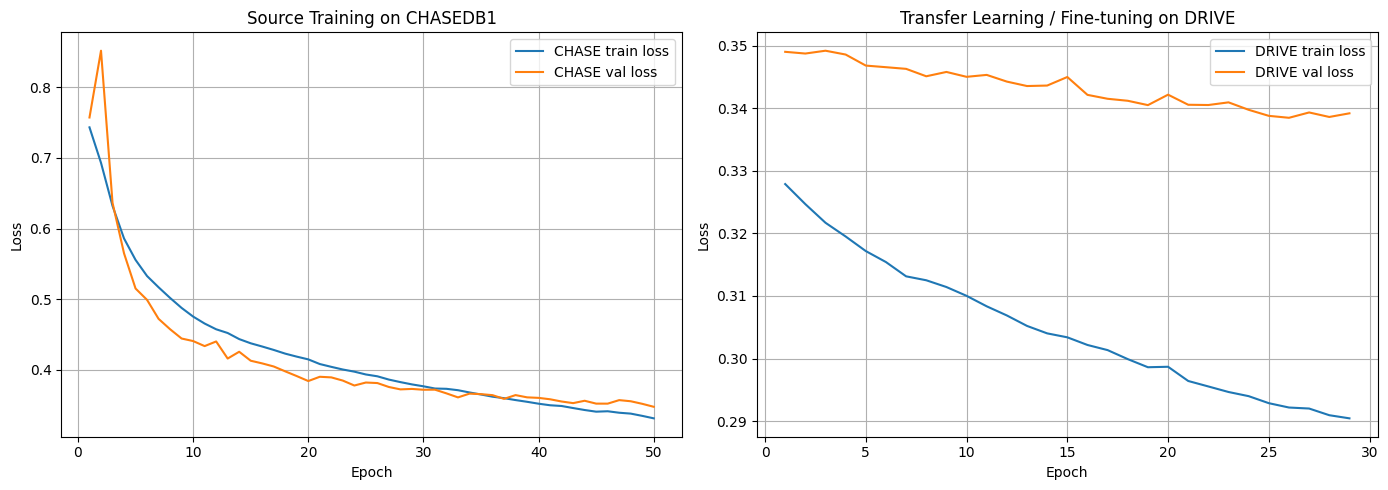

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(chase_history_df["epoch"], chase_history_df["train_loss"], label="CHASE train loss")
axes[0].plot(chase_history_df["epoch"], chase_history_df["val_loss"], label="CHASE val loss")
axes[0].set_title("Source Training on CHASEDB1")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(drive_history_df["epoch"], drive_history_df["train_loss"], label="DRIVE train loss")
axes[1].plot(drive_history_df["epoch"], drive_history_df["val_loss"], label="DRIVE val loss")
axes[1].set_title("Transfer Learning / Fine-tuning on DRIVE")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# LOAD BEST DRIVE MODEL + THRESHOLD SEARCH + FINAL EVALUATION
# ============================================================

best_drive_model = build_deeplabv3plus_resnet50(pretrained_backbone=False)

drive_ckpt = torch.load(
    DRIVE_BEST_MODEL_PATH,
    map_location="cpu"
)

load_model_state_dict_safely(
    best_drive_model,
    drive_ckpt["model_state_dict"]
)
del drive_ckpt
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print(f"Loaded best DRIVE checkpoint from {DRIVE_BEST_MODEL_PATH}")

# ============================================================
# Validation-based threshold search
# ============================================================

best_threshold, best_threshold_dice, threshold_df = find_best_threshold(
    model=best_drive_model,
    loader=drive_val_loader,
    device=DEVICE,
)

print("Best threshold:", best_threshold)
print("Best validation Dice:", best_threshold_dice)
threshold_df.to_csv(RESULTS_DIR / "threshold_search_drive.csv", index=False)
threshold_df

# ============================================================
# Final validation/test evaluation with best threshold
# ============================================================

val_metrics = evaluate_model(
    best_drive_model,
    drive_val_loader,
    drive_criterion,
    DEVICE,
    threshold=best_threshold
)

test_metrics = evaluate_model(
    best_drive_model,
    drive_test_loader,
    drive_criterion,
    DEVICE,
    threshold=best_threshold
)

if BEST_METRIC == "dice":
    best_idx = drive_history_df["val_dice"].idxmax()
else:
    best_idx = drive_history_df["val_iou"].idxmax()

drive_best_epoch = int(
    drive_history_df.loc[best_idx, "epoch"]
)

results_df = pd.DataFrame([
    {"dataset": "DRIVE", "split": "val", "epoch": drive_best_epoch, "threshold": best_threshold, **val_metrics},
    {"dataset": "DRIVE", "split": "test", "epoch": drive_best_epoch, "threshold": best_threshold, **test_metrics},
])

results_df.to_csv(RESULTS_DIR / "deeplabv3plus_resnet50_drive_test_results.csv", index=False)
print("Saved DRIVE test results to", RESULTS_DIR / "deeplabv3plus_resnet50_drive_test_results.csv")

results_df

Using 2 GPUs with DataParallel
Loaded best DRIVE checkpoint from /kaggle/working/best_deeplabv3_resnet50_drive.pth


,threshold,accuracy,precision,recall,f1,iou,dice,loss
1,0.45,0.924527,0.566974,0.689539,0.622279,0.451673,0.622279,0.340481
2,0.50,0.926986,0.583283,0.665951,0.621882,0.451254,0.621882,0.340481
0,0.40,0.921697,0.550804,0.712905,0.621457,0.450808,0.621458,0.340481
3,0.55,0.928914,0.598666,0.641834,0.619499,0.448749,0.619499,0.340481
4,0.60,0.930588,0.614917,0.615697,0.615306,0.444363,0.615307,0.340481


Best threshold based on validation Dice: 0.45
Saved DRIVE validation/test results to /kaggle/working/deeplabv3_resnet50_drive_results.csv
Saved threshold tuning results to /kaggle/working/drive_threshold_tuning.csv


,dataset,split,epoch,threshold,accuracy,precision,recall,f1,iou,dice,loss
0,DRIVE,val,19,0.45,0.924527,0.566974,0.689539,0.622279,0.451673,0.622279,0.340481
1,DRIVE,test,19,0.45,0.927983,0.570552,0.711560,0.633195,0.463274,0.633195,0.334790


## 8. Visualization: Image | Ground Truth | Prediction

The output visualization follows the same style as the SegFormer notebook and matches the expected issue result.

Using tuned best_threshold for visualization: 0.45


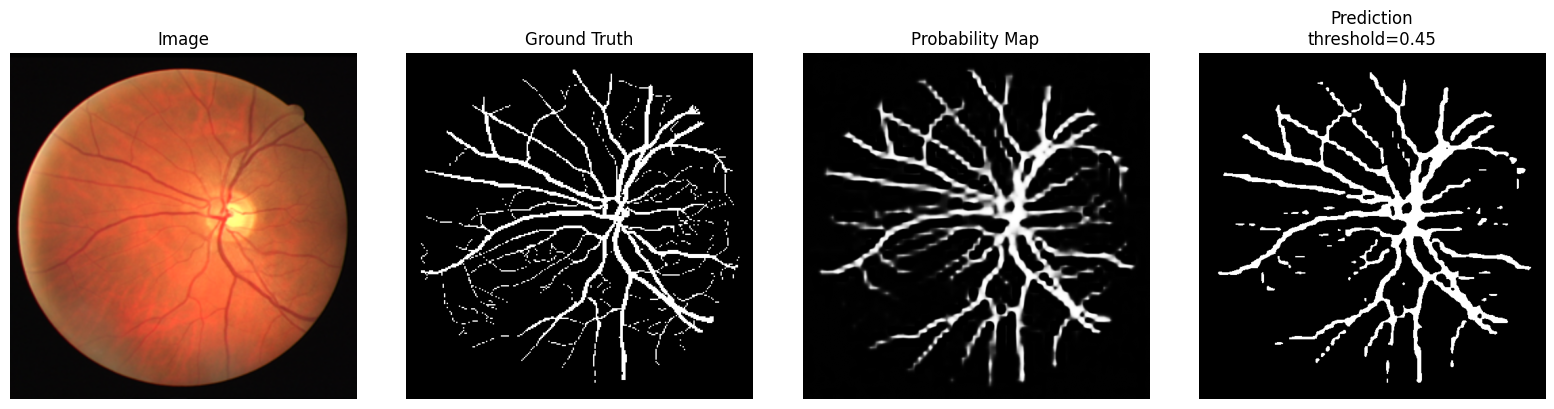

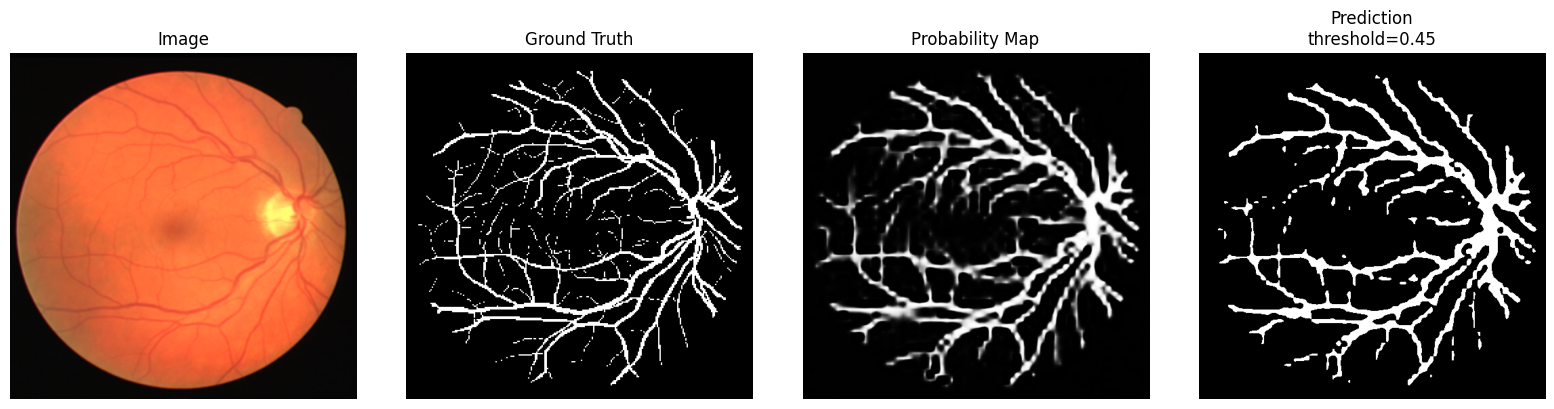

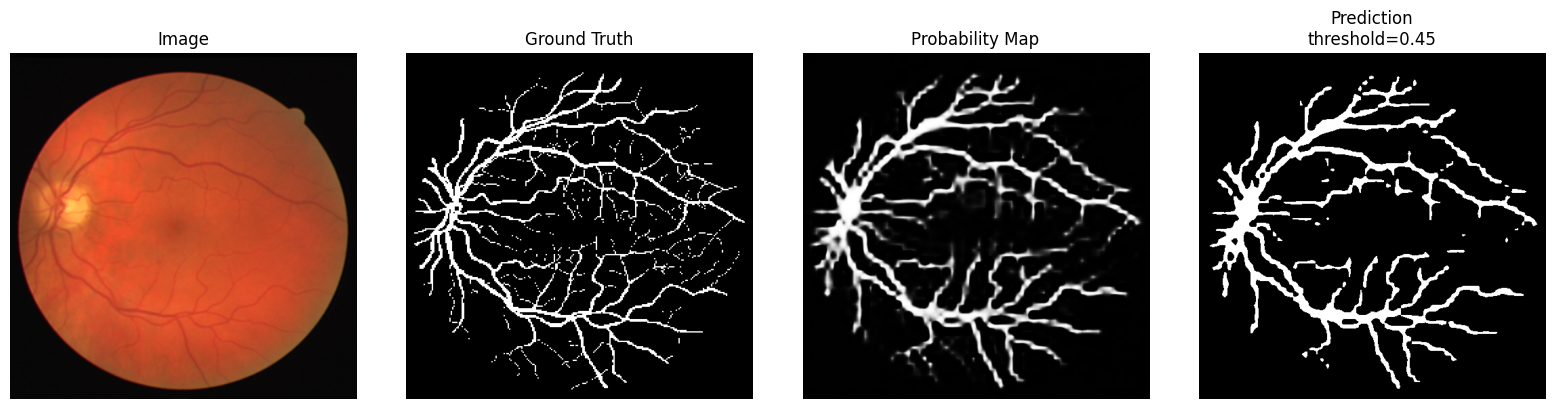

Saved 3 prediction figures to /kaggle/working/deeplabv3_resnet50_drive_predictions


[PosixPath('/kaggle/working/deeplabv3_resnet50_drive_predictions/prediction_013_thr_0.45.png'),
 PosixPath('/kaggle/working/deeplabv3_resnet50_drive_predictions/prediction_001_thr_0.45.png'),
 PosixPath('/kaggle/working/deeplabv3_resnet50_drive_predictions/prediction_014_thr_0.45.png')]

In [ ]:
# ============================================================
# VISUALIZATION: IMAGE | GROUND TRUTH | PREDICTION
# DeepLabV3+-ResNet50 DRIVE Test Visualization
# ============================================================

import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
import torch.nn.functional as F


IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)


def denorm_image(img: torch.Tensor) -> np.ndarray:
    img = img.detach().cpu()
    if img.dim() == 3 and img.shape[0] == 3:
        img = img.numpy()
        img = img * IMAGENET_STD[:, None, None] + IMAGENET_MEAN[:, None, None]
        img = np.clip(img, 0.0, 1.0)
        img = np.transpose(img, (1, 2, 0))
        return img
    return img.numpy()


def postprocess_binary_mask(pred: np.ndarray, min_area: int = 20, use_morphology: bool = True) -> np.ndarray:
    pred = pred.astype(np.uint8)

    if use_morphology:
        kernel = np.ones((2, 2), np.uint8)
        pred = cv2.morphologyEx(pred, cv2.MORPH_OPEN, kernel)
        pred = cv2.morphologyEx(pred, cv2.MORPH_CLOSE, kernel)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(pred, connectivity=8)
    clean = np.zeros_like(pred)

    for label_id in range(1, num_labels):
        area = stats[label_id, cv2.CC_STAT_AREA]
        if area >= min_area:
            clean[labels == label_id] = 1

    return clean.astype(np.float32)


def show_predictions(
    model,
    dataset,
    save_dir: Path,
    num_samples: int = 3,
    threshold: float = 0.5,
    seed: int = 42,
    use_postprocess: bool = True,
    min_area: int = 20,
    show_prob_map: bool = False,
    ):
    model.eval()
    save_dir.mkdir(parents=True, exist_ok=True)

    num_samples = min(num_samples, len(dataset))
    rng = np.random.default_rng(seed)
    idxs = rng.choice(len(dataset), size=num_samples, replace=False)

    saved_paths = []

    for idx in idxs:
        sample_id = int(idx)
        image, mask = dataset[sample_id]

        with torch.no_grad():
            logits = model(image.unsqueeze(0).to(DEVICE))
            if isinstance(logits, dict):
                logits = logits["out"]

            if logits.shape[-2:] != mask.shape[-2:]:
                logits = F.interpolate(logits, size=mask.shape[-2:], mode="bilinear", align_corners=False)

            prob = torch.sigmoid(logits)[0, 0].detach().cpu().numpy()

        pred = (prob > threshold).astype(np.float32)

        if use_postprocess:
            pred = postprocess_binary_mask(pred, min_area=min_area, use_morphology=True)

        image_np = denorm_image(image)
        mask_np = mask.squeeze(0).detach().cpu().numpy()

        if show_prob_map:
            fig, axes = plt.subplots(1, 4, figsize=(16, 4))
        else:
            fig, axes = plt.subplots(1, 3, figsize=(12, 4))

        axes[0].imshow(image_np)
        axes[0].set_title("Image")
        axes[0].axis("off")

        axes[1].imshow(mask_np, cmap="gray", vmin=0, vmax=1)
        axes[1].set_title("Ground Truth")
        axes[1].axis("off")

        if show_prob_map:
            axes[2].imshow(prob, cmap="gray", vmin=0, vmax=1)
            axes[2].set_title("Probability Map")
            axes[2].axis("off")

            axes[3].imshow(pred, cmap="gray", vmin=0, vmax=1)
            axes[3].set_title(f"Prediction\nthreshold={threshold:.2f}")
            axes[3].axis("off")
        else:
            axes[2].imshow(pred, cmap="gray", vmin=0, vmax=1)
            axes[2].set_title(f"Prediction\nthreshold={threshold:.2f}")
            axes[2].axis("off")

        plt.tight_layout()
        save_path = save_dir / f"prediction_{sample_id:03d}_thr_{threshold:.2f}.png"
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        saved_paths.append(save_path)

        plt.show()
        plt.close(fig)

    print(f"Saved {len(saved_paths)} prediction figures to {save_dir}")
    return saved_paths


prediction_paths = show_predictions(
    model=best_drive_model,
    dataset=drive_test_ds,
    save_dir=PREDICTIONS_DIR / "drive_test",
    num_samples=3,
    threshold=best_threshold,
    seed=SEED,
    use_postprocess=True,
    min_area=20,
    show_prob_map=False,
)

prediction_paths

In [ ]:
_ = show_predictions(
    model=best_drive_model,
    dataset=drive_test_ds,
    save_dir=PREDICTIONS_DIR / "drive_test_prob_map",
    num_samples=3,
    threshold=best_threshold,
    seed=SEED,
    use_postprocess=False,
    show_prob_map=True,
)

## DeepLabV3+-ResNet50 Improvement Summary

This notebook improves the DeepLabV3+-ResNet50 retinal vessel segmentation pipeline using:

- CHASEDB1 as the source dataset.
- DRIVE as the target dataset for transfer learning.
- BCE + Dice Loss with optional positive class weighting.
- Two-phase training: head-only warmup followed by full fine-tuning.
- Separate learning rates for the ResNet50 backbone and DeepLab classifier head.
- Validation-based threshold search instead of using a fixed threshold.
- Qualitative visualization in the format Image | Ground Truth | Prediction.

These changes are designed to improve segmentation of thin vessels, reduce false positives, and make the final threshold selection more reliable.

In [ ]:
summary = {
    "model": "DeepLabV3+-ResNet50",
    "source_dataset": "CHASEDB1",
    "target_dataset": "DRIVE",
    "training_method": "Transfer Learning: CHASEDB1 source training -> DRIVE fine-tuning",
    "img_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "best_metric": BEST_METRIC,
    "threshold": best_threshold if "best_threshold" in globals() else THRESHOLD,
    "save_dir": str(SAVE_DIR),
    "chase_best_checkpoint": str(CHASE_BEST_MODEL_PATH),
    "drive_best_checkpoint": str(DRIVE_BEST_MODEL_PATH),
    "chase_history_csv": str(CHASE_HISTORY_PATH),
    "drive_history_csv": str(DRIVE_HISTORY_PATH),
    "drive_results_csv": str(RESULTS_DIR / "deeplabv3plus_resnet50_drive_test_results.csv"),
    "threshold_search_csv": str(RESULTS_DIR / "threshold_search_drive.csv"),
    "drive_predictions_dir": str(PREDICTIONS_DIR / "drive_test"),
}
summary_df = pd.DataFrame(list(summary.items()), columns=["Item", "Value"])
summary_df

,Item,Value
0,model,DeepLabV3-ResNet50
1,source_dataset,CHASEDB1
2,target_dataset,DRIVE
3,training_method,Transfer Learning: CHASEDB1 source training ->...
4,img_size,512
5,batch_size,8
6,best_metric,dice
7,threshold,0.5
8,chase_best_checkpoint,/kaggle/working/best_deeplabv3_resnet50_chase.pth
9,drive_best_checkpoint,/kaggle/working/best_deeplabv3_resnet50_drive.pth
